Purpose: explore simulating ergodic processes and try to capture its properties through uncertainty bounds created out of conformal prediction.

Using Conformal Prediction to Test Ergodicity in a Simulated Environment
To apply conformal prediction to test ergodicity, you need to design an experiment where you:

Simulate an economic or time series process (e.g., wealth distribution, customer churn, financial returns).
Apply conformal prediction to estimate prediction intervals at different points in time.
Compare time-averaged vs. ensemble-averaged predictions to detect deviations that indicate non-ergodicity.
1. Understanding the Connection Between Conformal Prediction and Ergodicity
What is Conformal Prediction?
Conformal prediction is a distribution-free method that provides valid prediction intervals under minimal assumptions.
It works by measuring the nonconformity of new observations based on past data and adjusting prediction intervals to maintain a fixed confidence level.
How Does This Relate to Ergodicity?
Ergodicity means that time averages are equal to ensemble averages.
If a system is ergodic, then predictions based on time-series data for a single entity should match predictions based on many independent samples from the system.
Conformal prediction can be used to compare prediction intervals:
If the system is ergodic → The conformal prediction intervals over time should be similar to the intervals over an ensemble of realizations.
If the system is non-ergodic → The prediction intervals from individual trajectories (time averages) will systematically differ from the intervals derived from multiple trajectories (ensemble averages).
m

2. Designing a Simulated Experiment
To test ergodicity using conformal prediction, follow these steps:

Step 1: Simulate an Economic Process
Create two types of processes:
Ergodic Process: Example: A Gaussian random walk with a stable mean and variance.
Non-Ergodic Process: Example: A multiplicative stochastic process (e.g., wealth dynamics with path dependence).

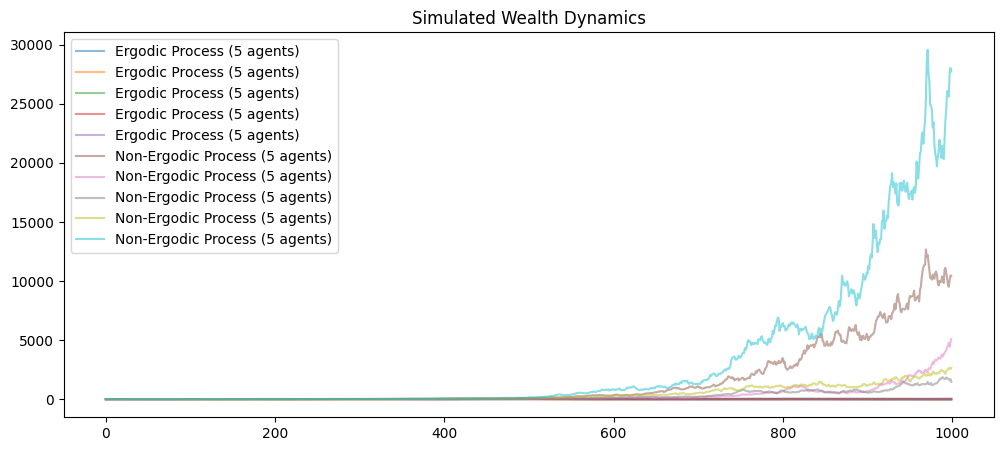

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulating an ergodic process (Additive Random Walk)
np.random.seed(42)
n_agents = 100  # Number of agents
n_periods = 1000  # Time steps

# Start from zero wealth
wealth_ergodic = np.zeros((n_agents, n_periods))

for t in range(1, n_periods):
    wealth_ergodic[:, t] = wealth_ergodic[:, t-1] + np.random.normal(0, 1, size=n_agents)

# Simulating a non-ergodic process (Multiplicative Wealth Growth)
wealth_non_ergodic = np.ones((n_agents, n_periods))

for t in range(1, n_periods):
    wealth_non_ergodic[:, t] = wealth_non_ergodic[:, t-1] * np.random.normal(1.01, 0.05, size=n_agents)

plt.figure(figsize=(12, 5))
plt.plot(wealth_ergodic[:5].T, alpha=0.5, label="Ergodic Process (5 agents)")
plt.plot(wealth_non_ergodic[:5].T, alpha=0.5, label="Non-Ergodic Process (5 agents)")
plt.legend()
plt.title("Simulated Wealth Dynamics")
plt.show()


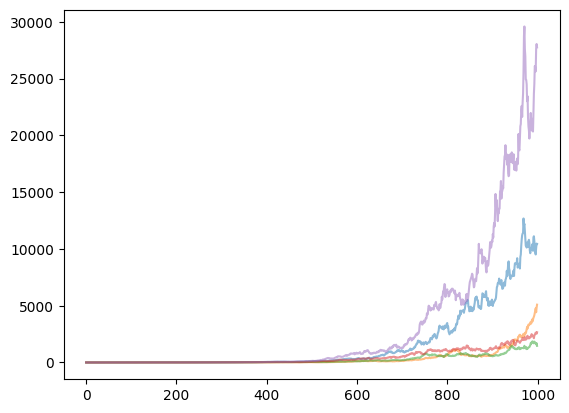

In [126]:
plt.plot(wealth_non_ergodic[:5].T, alpha=0.5, label="Non-Ergodic Process (5 agents)");


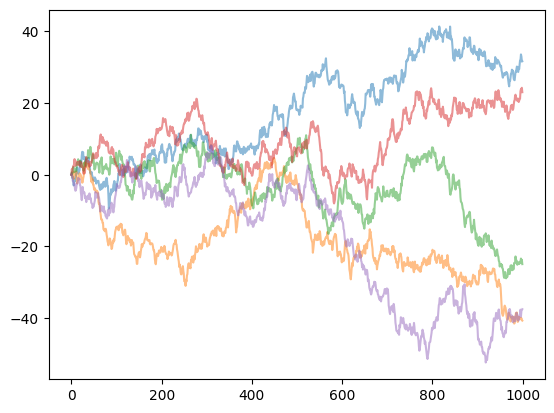

In [125]:
plt.plot(wealth_ergodic[:5].T, alpha=0.5, label="Ergodic Process (5 agents)");

Step 2: Apply Conformal Prediction

- Fit a conformal predictor on historical data.

- Compare the prediction intervals across different methods:

1. Time-Series Based Prediction: Predicting a single agent’s future value using past data.

2. Ensemble-Based Prediction: Predicting the next period for all agents based on the population distribution.

3. Using conformal prediction, we can compute prediction intervals for both cases:

In [124]:
# pip install nonconformist

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from nonconformist.cp import IcpRegressor
from nonconformist.nc import AbsErrorErrFunc, RegressorNc
from sklearn.model_selection import train_test_split


In [102]:
n_periods

500

In [105]:
# Prepare data for conformal prediction (Example: Ergodic Process)
X = np.arange(n_periods-1).reshape(-1, 1)  # Time step
Y = wealth_ergodic[0, :-1].reshape(-1, 1)  # One agent's wealth history

# First, split into training and temporary (calibration + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.4, random_state=42)

# Then split the temporary set into calibration and test
X_cal, X_test, y_cal, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [106]:
# Train a simple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [112]:

# Apply conformal prediction
nc = RegressorNc(model, AbsErrorErrFunc())
icp = IcpRegressor(nc)
icp.fit(X_train, y_train)
icp.calibrate(X_cal, y_cal)

In [111]:
X_cal.shape, X_test.shape

((200, 1), (200, 1))

There is an issue with this array

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Split into training, calibration, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
X_cal, X_test, y_cal, y_test = train_test_split(X_temp, y_temp, test_size=0.33, random_state=42)

# Ensure y_cal is a 1D array
y_cal = np.ravel(y_cal)

# Fit the model
icp.fit(X_train, y_train)

# Calibrate with enough data
icp.calibrate(X_cal, y_cal)

# Predict with adjusted significance level
pred_intervals = icp.predict(X_test, significance=0.1)  